# 01. Exploratory Data Analysis (EDA)

서울 아파트 실거래가 예측 데이터의 구조와 품질을 점검하고, 타깃 가격을 설명하는 주요 패턴을 탐색합니다. 분석 결과는 이후 전처리와 피처 엔지니어링의 근거로 사용합니다.

**분석 순서**
1. 데이터 로드 및 기본 구조 확인
2. 결측치·중복·범주 일관성 점검
3. 타깃 분포와 로그 변환 효과 확인
4. 지역·시간·면적·건축연도·교통 특성과 가격의 관계 분석
5. Train/Test 분포 비교 및 모델링 인사이트 정리

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 한글 폰트가 설치된 환경에서는 첫 번째 사용 가능한 폰트를 사용합니다.
plt.rcParams['font.family'] = ['AppleGothic', 'Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

## 1. 데이터 로드

In [5]:
# 프로젝트 루트와 notebooks 디렉터리 어디에서 실행해도 동작하도록 경로를 탐색합니다.
candidates = [Path.cwd() / 'data', Path.cwd().parent / 'data']
DATA_DIR = next((path for path in candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('data 디렉터리를 찾을 수 없습니다. 프로젝트 루트 또는 notebooks에서 실행하세요.')

train = pd.read_csv(DATA_DIR / 'seoul_real_estate_train.csv')
test = pd.read_csv(DATA_DIR / 'seoul_real_estate_test.csv')
submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'Train      : {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test       : {test.shape[0]:,} rows × {test.shape[1]} columns')
print(f'Submission : {submission.shape[0]:,} rows × {submission.shape[1]} columns')
display(train.head())

Train      : 1,969 rows × 11 columns
Test       : 531 rows × 10 columns
Submission : 531 rows × 2 columns


,ID,Gu,Dong,Exclusive_Area,Year_Built,Floor,Distance_to_Subway,Transaction_YearMonth,Brand_Apartment,Nearby_Parks,Target
0,TR_0960,Mapo-gu,Hapjeong,20.00,2012,6,0.48,202408,0,1,"17,572.00"
1,TR_0975,Songpa-gu,Garak,56.70,2002,23,0.30,202411,0,3,"35,592.00"
2,TR_2094,Gangnam-gu,Samsung,52.50,1977,10,0.81,202411,0,2,"41,944.00"
3,TR_1595,Eunpyeong-gu,Yeonsinnae,41.10,2002,4,0.16,202405,0,3,"17,465.00"
4,TR_1486,Eunpyeong-gu,Yeonsinnae,72.40,1983,31,0.20,202411,0,3,"32,301.00"


In [6]:
schema = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'train_unique': train.nunique(dropna=False),
    'train_missing': train.isna().sum(),
    'missing_rate(%)': train.isna().mean().mul(100),
})
schema['test_unique'] = test.nunique(dropna=False).reindex(train.columns)
schema['test_missing'] = test.isna().sum().reindex(train.columns)
display(schema)

,dtype,train_unique,train_missing,missing_rate(%),test_unique,test_missing
ID,object,1969,0,0.00,531.00,0.00
Gu,object,8,0,0.00,8.00,0.00
Dong,object,24,0,0.00,24.00,0.00
Exclusive_Area,float64,820,0,0.00,392.00,0.00
Year_Built,int64,49,0,0.00,49.00,0.00
Floor,int64,44,0,0.00,44.00,0.00
Distance_to_Subway,float64,844,54,2.74,376.00,21.00
Transaction_YearMonth,int64,24,0,0.00,3.00,0.00
Brand_Apartment,int64,2,0,0.00,2.00,0.00
Nearby_Parks,int64,5,0,0.00,5.00,0.00


## 2. 데이터 품질 점검

식별자 중복, 완전히 동일한 행, 결측치, Train/Test 사이의 범주 불일치를 확인합니다. 특히 베이스라인에서 중앙값으로 대체하는 `Distance_to_Subway` 결측 여부를 집중해서 봅니다.

In [7]:
quality = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(train), len(test)],
    'duplicate_rows': [train.duplicated().sum(), test.duplicated().sum()],
    'duplicate_IDs': [train['ID'].duplicated().sum(), test['ID'].duplicated().sum()],
    'total_missing': [train.isna().sum().sum(), test.isna().sum().sum()],
})
display(quality)

missing = pd.concat([
    train.isna().mean().mul(100).rename('train_missing(%)'),
    test.isna().mean().mul(100).rename('test_missing(%)')
], axis=1).fillna(0)
display(missing[missing.max(axis=1) > 0].sort_values('train_missing(%)', ascending=False))

,dataset,rows,duplicate_rows,duplicate_IDs,total_missing
0,train,1969,0,0,54
1,test,531,0,0,21


,train_missing(%),test_missing(%)
Distance_to_Subway,2.74,3.95


In [8]:
categorical_cols = ['Gu', 'Dong']
for col in categorical_cols:
    train_only = sorted(set(train[col].dropna()) - set(test[col].dropna()))
    test_only = sorted(set(test[col].dropna()) - set(train[col].dropna()))
    print(f'{col}: train에만 존재={train_only or "없음"}, test에만 존재={test_only or "없음"}')

# Dong이 하나의 Gu에만 속하는지 확인
dong_gu_count = pd.concat([train[['Gu', 'Dong']], test[['Gu', 'Dong']]]).drop_duplicates().groupby('Dong')['Gu'].nunique()
print(f'두 개 이상의 Gu에 연결된 Dong 수: {(dong_gu_count > 1).sum()}')

Gu: train에만 존재=없음, test에만 존재=없음
Dong: train에만 존재=없음, test에만 존재=없음
두 개 이상의 Gu에 연결된 Dong 수: 0


### 품질 점검 해석

- `ID`는 예측에 사용할 일반 특성이 아니라 제출 행을 식별하는 키입니다.
- `Distance_to_Subway` 결측치는 중앙값 대체와 함께 **결측 여부 자체를 나타내는 변수**도 후보가 됩니다.
- Test에만 존재하는 범주가 있다면 단순 LabelEncoder보다 미지 범주를 처리할 수 있는 인코딩이 안전합니다.

## 3. 수치형 변수와 타깃 분포

,count,mean,std,min,25%,50%,75%,max
Exclusive_Area,"1,969.00",70.44,24.85,20.00,53.40,70.30,86.60,148.70
Year_Built,"1,969.00","1,998.87",14.07,"1,975.00","1,987.00","1,999.00","2,011.00","2,023.00"
Floor,"1,969.00",21.72,12.58,1.00,11.00,21.00,33.00,44.00
Distance_to_Subway,"1,915.00",0.40,0.40,0.00,0.11,0.27,0.55,3.30
Transaction_YearMonth,"1,969.00","202,457.66",50.14,"202,401.00","202,407.00","202,501.00","202,506.00","202,512.00"
Brand_Apartment,"1,969.00",0.28,0.45,0.00,0.00,0.00,1.00,1.00
Nearby_Parks,"1,969.00",2.01,1.45,0.00,1.00,2.00,3.00,4.00
Target,"1,969.00","37,502.41","9,406.44","11,173.60","30,994.00","37,433.00","44,094.00","66,419.00"


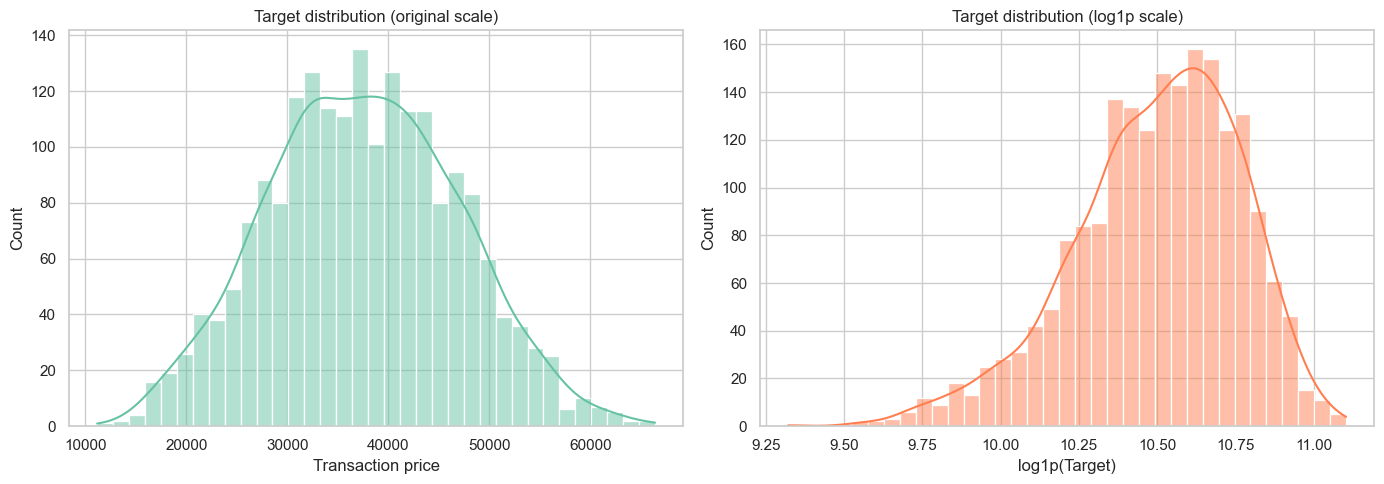

원본 왜도 : 0.078
로그 왜도 : -0.620


In [9]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
display(train[numeric_cols].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['Target'], bins=35, kde=True, ax=axes[0])
axes[0].set_title('Target distribution (original scale)')
axes[0].set_xlabel('Transaction price')

sns.histplot(np.log1p(train['Target']), bins=35, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Target distribution (log1p scale)')
axes[1].set_xlabel('log1p(Target)')
plt.tight_layout()
plt.show()

print(f'원본 왜도 : {train["Target"].skew():.3f}')
print(f'로그 왜도 : {np.log1p(train["Target"]).skew():.3f}')

In [10]:
# IQR 기준은 제거 규칙이 아니라 확인할 관측치를 찾는 보조 지표로만 사용합니다.
q1, q3 = train['Target'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
target_outliers = train[(train['Target'] < lower) | (train['Target'] > upper)]
print(f'IQR 경계: {lower:,.0f} ~ {upper:,.0f}')
print(f'IQR 기준 이상치 후보: {len(target_outliers):,}개 ({len(target_outliers) / len(train):.2%})')
display(target_outliers.sort_values('Target', ascending=False).head(10))

IQR 경계: 11,344 ~ 63,744
IQR 기준 이상치 후보: 4개 (0.20%)


,ID,Gu,Dong,Exclusive_Area,Year_Built,Floor,Distance_to_Subway,Transaction_YearMonth,Brand_Apartment,Nearby_Parks,Target
1947,TR_1693,Gangnam-gu,Daechi,133.40,2017,41,0.13,202503,0,3,"66,419.00"
304,TR_2402,Seocho-gu,Banpo,120.80,1990,18,1.12,202508,1,3,"66,360.00"
367,TR_2215,Gangnam-gu,Samsung,113.10,1981,15,0.07,202507,1,3,"64,352.00"
1521,TR_1447,Seongdong-gu,Oksu,38.50,2006,8,NaN,202410,1,3,"11,173.60"


## 4. 파생 변수 생성

베이스라인의 `Age`, 거래 연도·월을 재사용하고, 가격 수준을 비교할 때 면적 효과를 분리하기 위한 `Price_per_sqm`을 EDA 전용으로 만듭니다. `Price_per_sqm`은 Target에서 계산되므로 **학습 피처로 사용하면 데이터 누수**입니다.

In [11]:
def add_eda_features(df, include_target=True):
    result = df.copy()
    result['Transaction_Date'] = pd.to_datetime(result['Transaction_YearMonth'].astype(str), format='%Y%m')
    result['Transaction_Year'] = result['Transaction_YearMonth'] // 100
    result['Transaction_Month'] = result['Transaction_YearMonth'] % 100
    result['Age_at_Transaction'] = result['Transaction_Year'] - result['Year_Built']
    result['Subway_Distance_Missing'] = result['Distance_to_Subway'].isna().astype('int8')
    if include_target:
        result['Log_Target'] = np.log1p(result['Target'])
        result['Price_per_sqm'] = result['Target'] / result['Exclusive_Area']
    return result

train_eda = add_eda_features(train)
test_eda = add_eda_features(test, include_target=False)
display(train_eda.head())

,ID,Gu,Dong,Exclusive_Area,Year_Built,Floor,Distance_to_Subway,Transaction_YearMonth,Brand_Apartment,Nearby_Parks,Target,Transaction_Date,Transaction_Year,Transaction_Month,Age_at_Transaction,Subway_Distance_Missing,Log_Target,Price_per_sqm
0,TR_0960,Mapo-gu,Hapjeong,20.00,2012,6,0.48,202408,0,1,"17,572.00",2024-08-01,2024,8,12,0,9.77,878.60
1,TR_0975,Songpa-gu,Garak,56.70,2002,23,0.30,202411,0,3,"35,592.00",2024-11-01,2024,11,22,0,10.48,627.72
2,TR_2094,Gangnam-gu,Samsung,52.50,1977,10,0.81,202411,0,2,"41,944.00",2024-11-01,2024,11,47,0,10.64,798.93
3,TR_1595,Eunpyeong-gu,Yeonsinnae,41.10,2002,4,0.16,202405,0,3,"17,465.00",2024-05-01,2024,5,22,0,9.77,424.94
4,TR_1486,Eunpyeong-gu,Yeonsinnae,72.40,1983,31,0.20,202411,0,3,"32,301.00",2024-11-01,2024,11,41,0,10.38,446.15


## 5. 지역별 가격 차이

,Transactions,Median_Price,Mean_Price,Median_Price_per_sqm
Gu,,,,
Gangnam-gu,243,"46,667.00","46,532.70",668.84
Seocho-gu,212,"43,385.00","43,320.74",605.57
Yongsan-gu,239,"41,295.00","41,671.92",595.93
Songpa-gu,248,"40,484.50","40,377.23",566.46
Mapo-gu,261,"35,328.00","35,113.01",493.51
Seongdong-gu,264,"34,916.50","35,529.22",505.52
Nowon-gu,251,"30,285.00","30,195.99",421.62
Eunpyeong-gu,251,"28,588.00","28,901.42",415.40


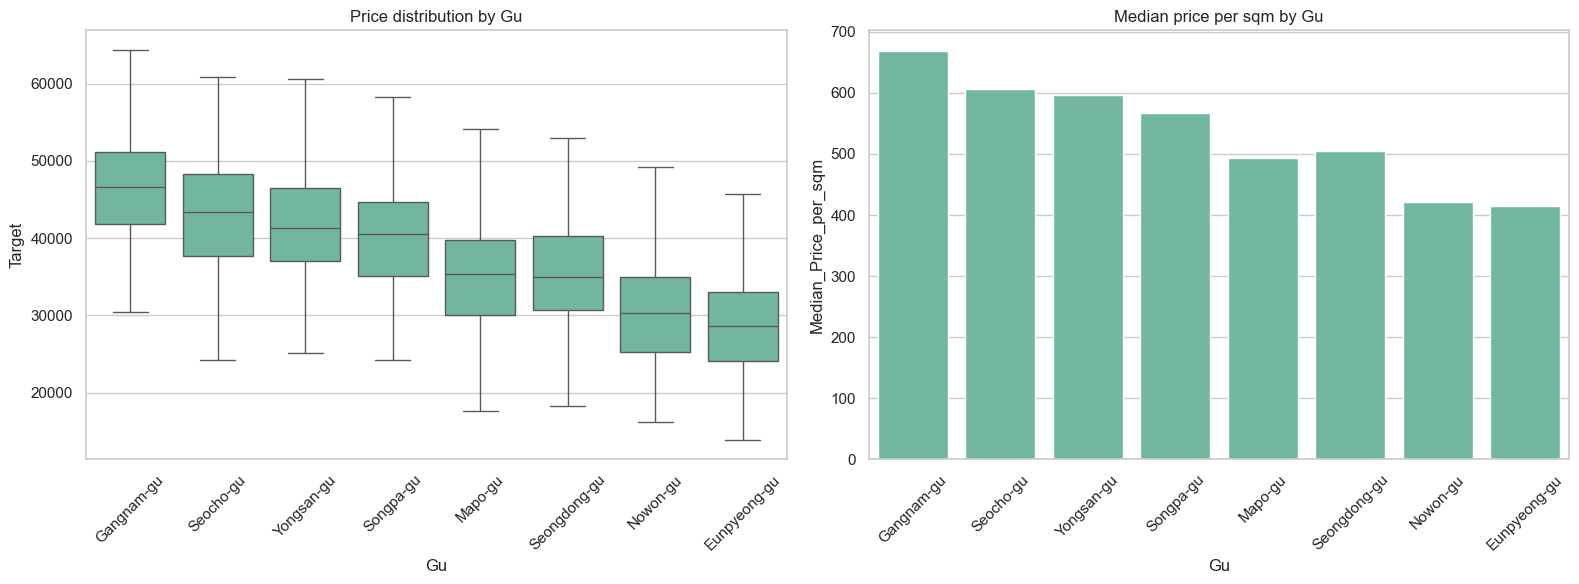

In [12]:
gu_summary = (train_eda.groupby('Gu')
              .agg(Transactions=('Target', 'size'),
                   Median_Price=('Target', 'median'),
                   Mean_Price=('Target', 'mean'),
                   Median_Price_per_sqm=('Price_per_sqm', 'median'))
              .sort_values('Median_Price', ascending=False))
display(gu_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=train_eda, x='Gu', y='Target', order=gu_summary.index, showfliers=False, ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Price distribution by Gu')
sns.barplot(data=gu_summary.reset_index(), x='Gu', y='Median_Price_per_sqm', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Median price per sqm by Gu')
plt.tight_layout()
plt.show()

Transactions  Median_Price  Median_Price_per_sqm
Gu           Dong                                                        
Gangnam-gu   Samsung               71     46,693.00                704.81
             Apgujeong             93     46,772.00                670.49
             Daechi                79     46,429.00                633.22
Seocho-gu    Seocho                92     43,359.50                614.04
Yongsan-gu   Hannam                85     41,134.00                610.06
Seocho-gu    Bangbae               53     43,645.00                604.79
Yongsan-gu   Ichon                 83     40,979.00                597.40
Seocho-gu    Banpo                 67     43,265.00                596.08
Yongsan-gu   Itaewon               71     43,475.00                587.89
Songpa-gu    Jamsil                78     40,946.00                573.79
             Munjjeong             84     40,816.50                568.75
             Garak                 86     40,312.00                551.72
Seongdong-gu Seongsu               86     34,253.50                511.96
             Geumho                97     34,761.00                506.72
Mapo-gu      Ahyeon               100     35,714.00                496.02
             Hapjeong              79     33,187.00                493.84
Seongdong-gu Oksu                  81     36,606.00                493.79
Mapo-gu      Sangam                82     36,067.00                492.54
Nowon-gu     Junggye               75     31,095.00                424.43
             Sanggye               96     28,186.50                420.17
             Wolgye                80     30,521.50                419.76
Eunpyeong-gu Yeonsinnae            76     29,706.00                417.65
             Susaek                87     29,115.00                415.40
             Bulgwang              88     27,573.00                412.50

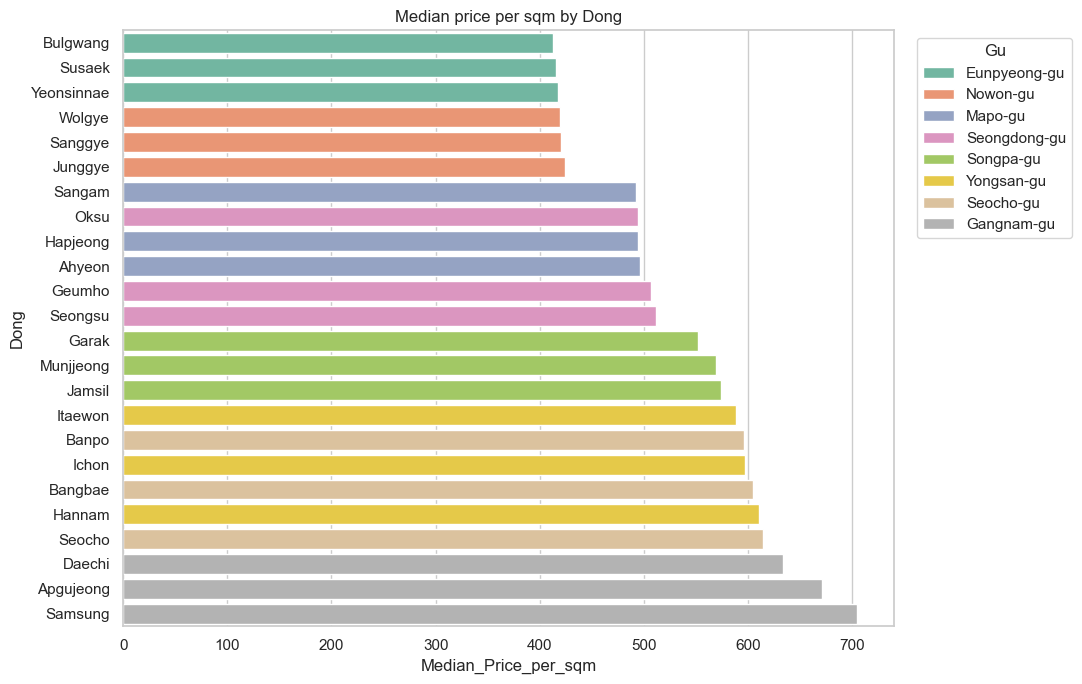

In [13]:
dong_summary = (train_eda.groupby(['Gu', 'Dong'])
                .agg(Transactions=('Target', 'size'),
                     Median_Price=('Target', 'median'),
                     Median_Price_per_sqm=('Price_per_sqm', 'median'))
                .sort_values('Median_Price_per_sqm', ascending=False))
display(dong_summary)

plt.figure(figsize=(11, 7))
plot_data = dong_summary.reset_index().sort_values('Median_Price_per_sqm')
sns.barplot(data=plot_data, y='Dong', x='Median_Price_per_sqm', hue='Gu', dodge=False)
plt.title('Median price per sqm by Dong')
plt.legend(title='Gu', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. 시간에 따른 가격 변화

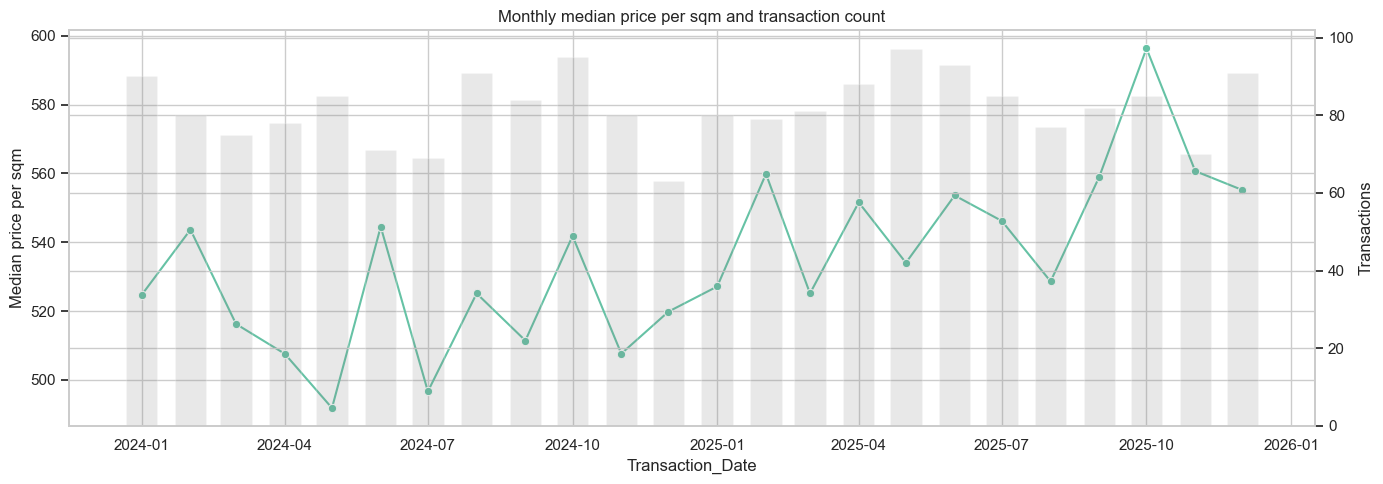

Train 기간: 2024-01-01 ~ 2025-12-01
Test 기간 : 2026-01-01 ~ 2026-03-01


In [14]:
monthly = (train_eda.groupby('Transaction_Date')
           .agg(Transactions=('Target', 'size'),
                Median_Price=('Target', 'median'),
                Median_Price_per_sqm=('Price_per_sqm', 'median'))
           .reset_index())

fig, ax1 = plt.subplots(figsize=(14, 5))
sns.lineplot(data=monthly, x='Transaction_Date', y='Median_Price_per_sqm', marker='o', ax=ax1)
ax1.set_title('Monthly median price per sqm and transaction count')
ax1.set_ylabel('Median price per sqm')
ax2 = ax1.twinx()
ax2.bar(monthly['Transaction_Date'], monthly['Transactions'], width=20, alpha=0.18, color='gray')
ax2.set_ylabel('Transactions')
plt.tight_layout()
plt.show()

print('Train 기간:', train_eda['Transaction_Date'].min().date(), '~', train_eda['Transaction_Date'].max().date())
print('Test 기간 :', test_eda['Transaction_Date'].min().date(), '~', test_eda['Transaction_Date'].max().date())

## 7. 주요 수치 특성과 가격의 관계

원가격과 로그가격 모두 확인합니다. 절대 거래가는 면적의 영향을 크게 받으므로, 지역·교통·노후도 효과는 면적당 가격과 함께 해석합니다.

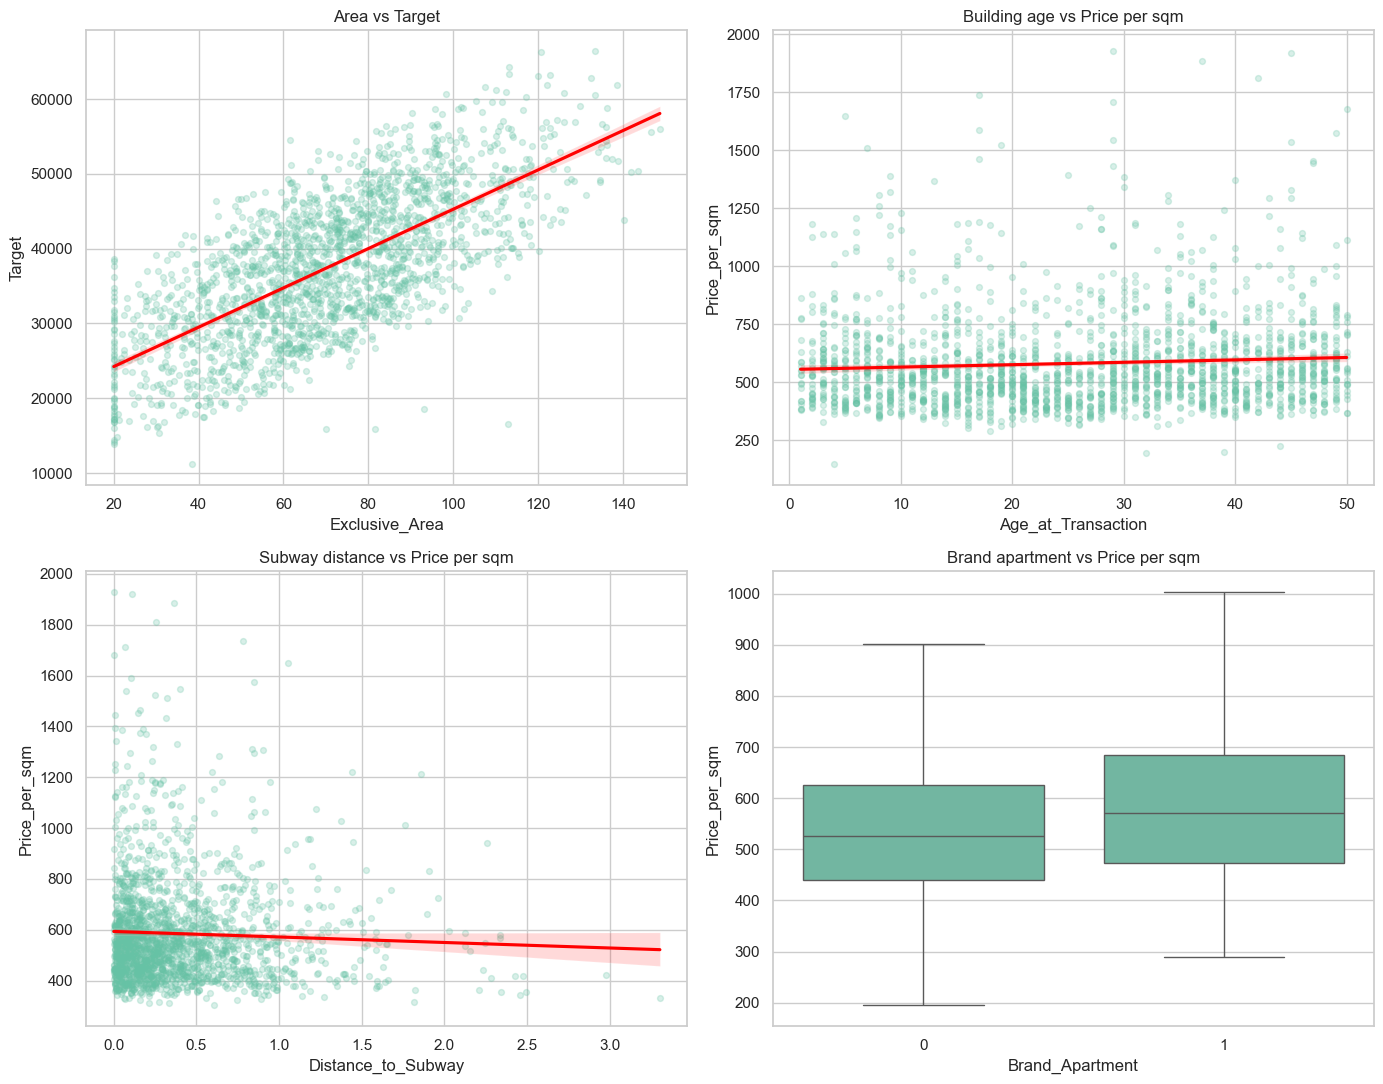

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
sns.regplot(data=train_eda, x='Exclusive_Area', y='Target', scatter_kws={'alpha': 0.25, 's': 18}, line_kws={'color': 'red'}, ax=axes[0, 0])
axes[0, 0].set_title('Area vs Target')
sns.regplot(data=train_eda, x='Age_at_Transaction', y='Price_per_sqm', scatter_kws={'alpha': 0.25, 's': 18}, line_kws={'color': 'red'}, ax=axes[0, 1])
axes[0, 1].set_title('Building age vs Price per sqm')
sns.regplot(data=train_eda, x='Distance_to_Subway', y='Price_per_sqm', scatter_kws={'alpha': 0.25, 's': 18}, line_kws={'color': 'red'}, ax=axes[1, 0])
axes[1, 0].set_title('Subway distance vs Price per sqm')
sns.boxplot(data=train_eda, x='Brand_Apartment', y='Price_per_sqm', showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title('Brand apartment vs Price per sqm')
plt.tight_layout()
plt.show()

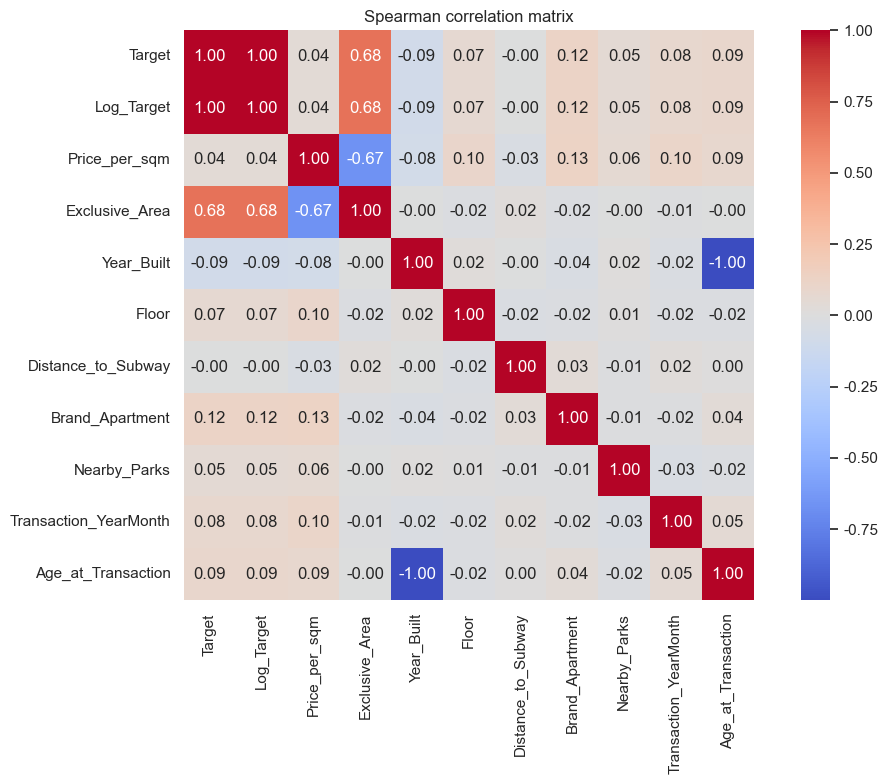

,Target,Log_Target,Price_per_sqm
Target,1.00,1.00,0.04
Log_Target,1.00,1.00,0.04
Exclusive_Area,0.68,0.68,-0.67
Brand_Apartment,0.12,0.12,0.13
Age_at_Transaction,0.09,0.09,0.09
Transaction_YearMonth,0.08,0.08,0.10
Floor,0.07,0.07,0.10
Nearby_Parks,0.05,0.05,0.06
Price_per_sqm,0.04,0.04,1.00
Distance_to_Subway,-0.00,-0.00,-0.03


In [16]:
corr_cols = ['Target', 'Log_Target', 'Price_per_sqm', 'Exclusive_Area', 'Year_Built',
             'Floor', 'Distance_to_Subway', 'Brand_Apartment', 'Nearby_Parks',
             'Transaction_YearMonth', 'Age_at_Transaction']
corr = train_eda[corr_cols].corr(method='spearman')

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Spearman correlation matrix')
plt.tight_layout()
plt.show()
display(corr[['Target', 'Log_Target', 'Price_per_sqm']].sort_values('Target', ascending=False))

## 8. Train/Test 분포 비교

,train_mean,test_mean,train_median,test_median
Exclusive_Area,70.44,70.66,70.30,70.10
Year_Built,"1,998.87","1,999.49","1,999.00","1,999.00"
Floor,21.72,22.65,21.00,23.00
Distance_to_Subway,0.40,0.39,0.27,0.29
Brand_Apartment,0.28,0.32,0.00,0.00
Nearby_Parks,2.01,2.11,2.00,2.00
Transaction_YearMonth,"202,457.66","202,602.00","202,501.00","202,602.00"


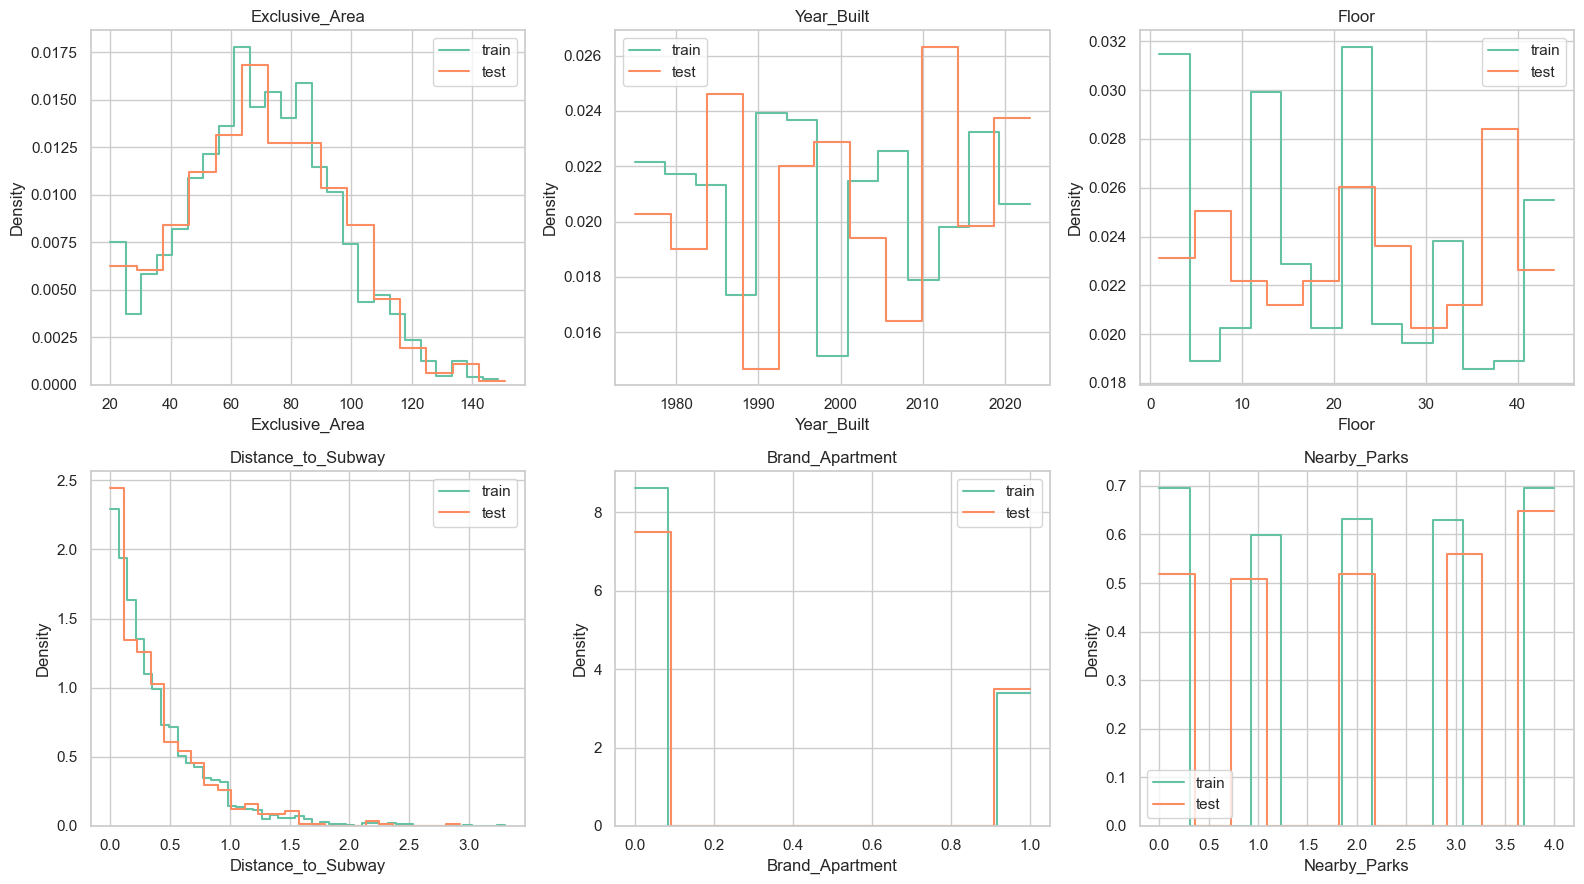

In [17]:
compare_cols = ['Exclusive_Area', 'Year_Built', 'Floor', 'Distance_to_Subway',
                'Brand_Apartment', 'Nearby_Parks', 'Transaction_YearMonth']
distribution_summary = pd.DataFrame(index=compare_cols)
for col in compare_cols:
    distribution_summary.loc[col, 'train_mean'] = train[col].mean()
    distribution_summary.loc[col, 'test_mean'] = test[col].mean()
    distribution_summary.loc[col, 'train_median'] = train[col].median()
    distribution_summary.loc[col, 'test_median'] = test[col].median()
display(distribution_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(compare_cols[:6], axes.flat):
    sns.histplot(train[col], stat='density', element='step', fill=False, label='train', ax=ax)
    sns.histplot(test[col], stat='density', element='step', fill=False, label='test', ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

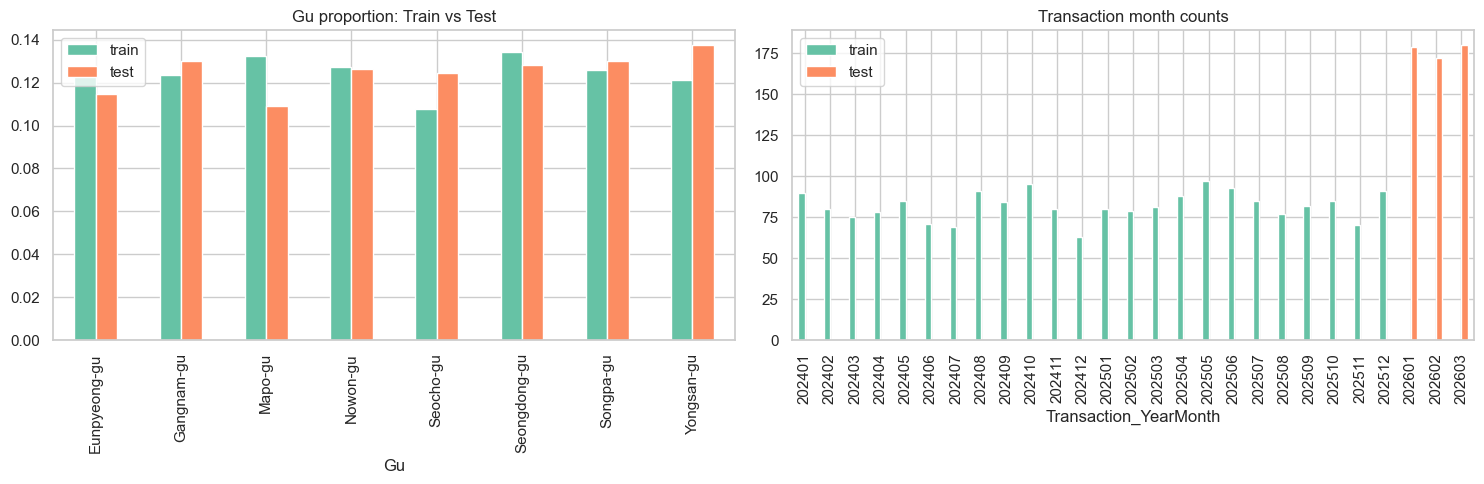

,train,test
Gu,,
Eunpyeong-gu,0.13,0.11
Gangnam-gu,0.12,0.13
Mapo-gu,0.13,0.11
Nowon-gu,0.13,0.13
Seocho-gu,0.11,0.12
Seongdong-gu,0.13,0.13
Songpa-gu,0.13,0.13
Yongsan-gu,0.12,0.14


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
gu_share = pd.concat([
    train['Gu'].value_counts(normalize=True).rename('train'),
    test['Gu'].value_counts(normalize=True).rename('test')
], axis=1).fillna(0).sort_index()
gu_share.plot(kind='bar', ax=axes[0], title='Gu proportion: Train vs Test')

time_counts = pd.concat([
    train['Transaction_YearMonth'].value_counts().rename('train'),
    test['Transaction_YearMonth'].value_counts().rename('test')
], axis=1).fillna(0).sort_index()
time_counts.plot(kind='bar', ax=axes[1], title='Transaction month counts')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()
display(gu_share)

## 9. EDA 결론과 모델링 제안

노트북 실행 결과를 바탕으로 다음 사항을 모델링에 반영합니다.

1. **타깃 변환**: 가격 분포의 오른쪽 꼬리를 완화하고 RMSLE에 맞추기 위해 베이스라인처럼 `log1p(Target)`을 학습합니다.
2. **지역 정보**: `Gu`, `Dong`별 가격 수준 차이가 크므로 핵심 범주형 변수로 유지합니다. `Gu × Dong` 결합 변수나 교차검증 기반 타깃 인코딩도 후보입니다.
3. **시간 정보**: Train과 Test의 거래 시점이 이어지는 구조라면 무작위 분할 점수는 낙관적일 수 있습니다. 최신 기간을 검증 세트로 두는 시간 순서 검증을 함께 사용합니다.
4. **건물 특성**: 거래 시점 기준 노후도(`Transaction_Year - Year_Built`), 면적 구간, 층 구간과 같은 비선형 파생 변수를 검토합니다.
5. **교통 결측치**: `Distance_to_Subway`는 중앙값으로 대체하되 `Subway_Distance_Missing`을 함께 둡니다.
6. **이상치**: 고가 거래는 실제 지역·면적 효과일 수 있으므로 IQR만으로 제거하지 않고 원자료 오류 여부를 확인합니다.
7. **데이터 누수 주의**: `Price_per_sqm`과 지역별 Target 집계값은 EDA에는 유용하지만, 검증 폴드 밖의 Target으로 계산해 학습에 넣으면 누수가 발생합니다.

이 결과는 `02_baseline_lgbm.ipynb`와 `03_feature_engineering.ipynb`에서 검증 전략 및 파생 변수 설계의 근거로 사용할 수 있습니다.